# Módulo 7 — La sonrisa de volatilidad

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas
**Autor:** Jorge Rodríguez Lázaro
**Última actualización:** 2026-09-26

---

## Objetivo del módulo

Cierre del proyecto con una pieza corta pero reveladora, que conecta todos los hilos anteriores. A lo largo de los módulos hemos usado Black-Scholes con una **volatilidad $\sigma$ constante**. Y en los Módulos 2 y 4 vimos que las rentabilidades reales tienen **colas gruesas** que el modelo normal ignora. ¿Cómo se manifiesta ese fallo en el *mercado de opciones*?

La respuesta es uno de los hechos más famosos de las finanzas: la **sonrisa de volatilidad** (*volatility smile/skew*). Si tomamos precios de opciones e **invertimos Black-Scholes** para averiguar qué $\sigma$ reproduce cada precio —la *volatilidad implícita*—, descubrimos que **no es constante**: depende del strike. Black-Scholes predice una línea plana; el mercado dibuja una sonrisa (o, en renta variable, una mueca inclinada). Es la huella digital, visible y cotizada, de que el supuesto gaussiano es falso.

## Estructura

| Sección | Tema | Idea clave |
|---------|------|------------|
| 1 | Volatilidad implícita | Invertir Black-Scholes: la $\sigma$ que casa con el precio de mercado. |
| 2 | Un mercado con colas gruesas | Simular precios bajo un modelo con saltos (Merton). |
| 3 | La sonrisa | Invertir e interpretar; conexión con las colas de los Módulos 2 y 4. |

## Referencias

- Merton, R. (1976). *Option Pricing when Underlying Stock Returns are Discontinuous*. J. Financial Economics.
- Gatheral, J. (2006). *The Volatility Surface: A Practitioner's Guide*.
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, cap. 20.

> **Nota sobre el código.** Reutiliza `mcquant.black_scholes`; la inversión de la volatilidad implícita y el modelo de saltos se implementan *inline*.

---

# Sección 1 — Volatilidad implícita

## 1.1 Invertir Black-Scholes

La fórmula de Black-Scholes toma $(S_0, K, r, \sigma, T)$ y devuelve un precio. Pero en el mercado ocurre al revés: **observamos el precio** de la opción y todos los parámetros *excepto* $\sigma$. La **volatilidad implícita** es el valor de $\sigma$ que, metido en Black-Scholes, reproduce exactamente el precio de mercado:

$$
\text{Precio}_{\text{mercado}} = \text{BlackScholes}(S_0, K, r, \sigma_{\text{impl}}, T)
$$

Como el precio de Black-Scholes es estrictamente creciente en $\sigma$, esta ecuación tiene solución única y se resuelve numéricamente (aquí, con el método de Brent). Si el mundo fuera realmente Black-Scholes, la $\sigma_{\text{impl}}$ sería **idéntica para todos los strikes** — la misma volatilidad del activo. La gracia está en que no lo es.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from mcquant import black_scholes

rng = np.random.default_rng(seed=42)


def vol_implicita(precio, S0, K, r, T, tipo='call'):
    '''Volatilidad implícita: la sigma que reproduce el precio dado (Black-Scholes).'''
    objetivo = lambda s: black_scholes(S0, K, r, s, T, tipo) - precio
    try:
        return brentq(objetivo, 1e-4, 5.0)
    except ValueError:
        return np.nan   # precio fuera del rango sin arbitraje

# Comprobación: si el precio viene de BS con sigma=0.2, la implícita debe ser 0.2
p = black_scholes(100, 110, 0.05, 0.20, 1.0, 'call')
print(f"Precio BS con sigma=0.20:  {p:.4f}")
print(f"Volatilidad implícita recuperada: {vol_implicita(p, 100, 110, 0.05, 1.0):.4f}")

Precio BS con sigma=0.20:  6.0401
Volatilidad implícita recuperada: 0.2000


---

# Sección 2 — Un mercado con colas gruesas

## 2.1 Por qué necesitamos un modelo mejor que el GBM

Para *ver* la sonrisa necesitamos precios de opciones que **no** vengan de Black-Scholes (si vinieran de BS, la implícita sería plana por construcción). Usamos un modelo más realista que sí genera colas gruesas y, por tanto, sonrisa: el **modelo de saltos de Merton (1976)**, que añade al GBM saltos súbitos:

$$
S_T = S_0 \exp\!\left(\Big(r - \lambda\kappa - \tfrac{\sigma^2}{2}\Big)T + \sigma\sqrt{T}\,Z + \sum_{i=1}^{N_T} J_i\right)
$$

donde $N_T \sim \text{Poisson}(\lambda T)$ cuenta los saltos, cada salto $J_i \sim \mathcal{N}(\mu_J, \sigma_J^2)$, y $\kappa = e^{\mu_J + \sigma_J^2/2} - 1$ es la corrección de deriva que mantiene la valoración neutral al riesgo. Con $\mu_J < 0$ (saltos a la baja, "riesgo de desplome") el modelo produce una cola izquierda gruesa — exactamente la asimetría que medimos en el SPY real (Módulo 4).

Valoramos las opciones bajo Merton por Monte Carlo. Para que la sonrisa salga suave, usamos **los mismos números aleatorios** para todos los strikes (simulamos $S_T$ una vez y valoramos todos los strikes sobre esa muestra).

In [2]:
def simular_ST_merton(S0, r, sigma, T, lam, muJ, sigJ, N, rng):
    kappa = np.exp(muJ + 0.5 * sigJ**2) - 1.0
    Z = rng.standard_normal(N)
    n_saltos = rng.poisson(lam * T, N)                       # nº de saltos por trayectoria
    salto_total = rng.normal(n_saltos * muJ, np.sqrt(n_saltos) * sigJ)
    deriva = (r - lam * kappa - 0.5 * sigma**2) * T
    return S0 * np.exp(deriva + sigma * np.sqrt(T) * Z + salto_total)


# Parámetros del "mercado" (Merton con riesgo de desplome)
S0, r, T = 100.0, 0.05, 1.0
sigma_dif, lam, muJ, sigJ = 0.15, 1.0, -0.10, 0.15
N = 3_000_000

ST = simular_ST_merton(S0, r, sigma_dif, T, lam, muJ, sigJ, N, rng)

strikes = np.arange(75, 126, 2.5)
precios = np.array([np.exp(-r * T) * np.maximum(ST - K, 0.0).mean() for K in strikes])
print(f"Simuladas {N:,} trayectorias bajo Merton; {len(strikes)} strikes valorados.")
print(f"E[S_T] simulado = {np.exp(-r*T)*ST.mean():.4f}  (debe ser ~S0 = {S0}, martingala)")

Simuladas 3,000,000 trayectorias bajo Merton; 21 strikes valorados.
E[S_T] simulado = 100.0179  (debe ser ~S0 = 100.0, martingala)


---

# Sección 3 — La sonrisa

Invertimos Black-Scholes en cada strike para obtener la volatilidad implícita, y la dibujamos frente a la volatilidad *difusiva* real del modelo ($\sigma = 0.15$), que es lo que Black-Scholes "debería" ver si el mundo fuera lognormal.

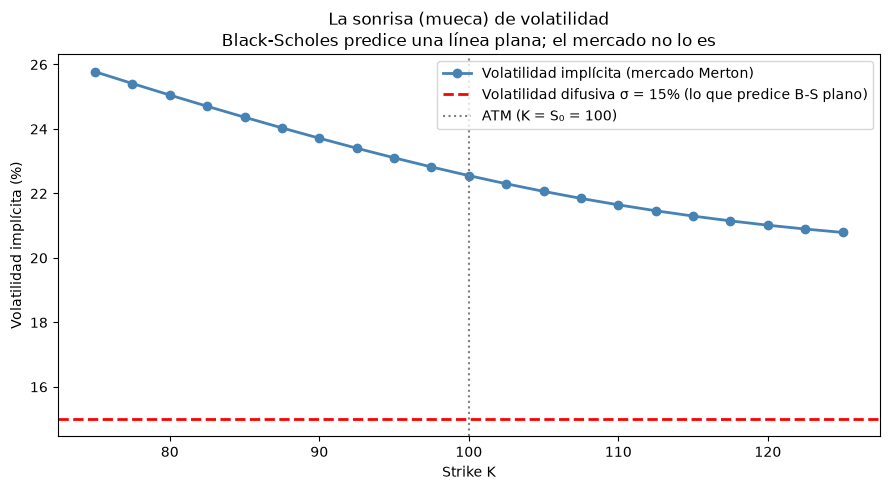

Vol implícita ATM:                0.2255
Vol implícita strike bajo (K=75): 0.2578  <- protección contra caídas, más cara
Vol implícita strike alto (K=125):0.2079
Pendiente (skew): la implícita CAE al subir el strike → mueca de renta variable


In [3]:
iv = np.array([vol_implicita(p, S0, K, r, T) for p, K in zip(precios, strikes)])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(strikes, iv * 100, 'o-', color='steelblue', linewidth=2, label='Volatilidad implícita (mercado Merton)')
ax.axhline(sigma_dif * 100, color='red', linestyle='--', linewidth=2,
           label=f'Volatilidad difusiva σ = {sigma_dif:.0%} (lo que predice B-S plano)')
ax.axvline(S0, color='gray', linestyle=':', label=f'ATM (K = S₀ = {S0:.0f})')
ax.set_xlabel('Strike K'); ax.set_ylabel('Volatilidad implícita (%)')
ax.set_title('La sonrisa (mueca) de volatilidad\nBlack-Scholes predice una línea plana; el mercado no lo es')
ax.legend(); plt.tight_layout(); plt.show()

atm = np.interp(S0, strikes, iv)
print(f"Vol implícita ATM:                {atm:.4f}")
print(f"Vol implícita strike bajo (K=75): {iv[0]:.4f}  <- protección contra caídas, más cara")
print(f"Vol implícita strike alto (K=125):{iv[-1]:.4f}")
print(f"Pendiente (skew): la implícita CAE al subir el strike → mueca de renta variable")

## 3.1 Interpretación: la sonrisa es la cola gruesa cotizada

Lo que vemos es la **mueca de volatilidad de renta variable** (*equity skew*): la volatilidad implícita es **más alta para strikes bajos** (opciones de protección ante caídas) y baja al subir el strike. Su significado es directo y cierra el arco de todo el proyecto:

- Los strikes bajos protegen contra **desplomes**. Como el modelo con saltos (y el mercado real) asigna a esos desplomes **mucha más probabilidad** que la campana de Gauss —la cola izquierda gruesa del Módulo 4—, esas opciones valen más. Y "más caras", traducido al lenguaje de Black-Scholes, significa **mayor volatilidad implícita**.
- Es decir: **la sonrisa es la cola gruesa expresada en el único lenguaje que el mercado cotiza, el de la volatilidad de Black-Scholes.** El mercado *sabe* que el GBM subestima los extremos, y lo cobra.

Si el activo siguiera de verdad un GBM (rentabilidades normales, sin saltos), la línea azul sería plana y coincidiría con la roja. La curvatura mide exactamente cuánto se aparta la realidad del modelo — y por eso los operadores cotizan y negocian *en volatilidad implícita*, no en precios: es su medida directa de esa desviación.

## Cierre del proyecto

Con esta pieza cerramos el recorrido completo. Empezamos en el Módulo 1 con el azar más puro —estimar $\pi$ tirando dardos— y terminamos leyendo, en la curvatura de la sonrisa de volatilidad, el precio que el mercado pone a lo que los modelos no capturan. En medio: construimos un modelo de precios (GBM) y descubrimos que su tendencia es inestimable; valoramos opciones esquivando ese problema con la neutralidad al riesgo; medimos el riesgo de cola y vimos dónde el modelo se rompe; y dominamos el oficio del método (reducción de varianza, Griegas, americanas por regresión).

El hilo conductor, del primer módulo al último, ha sido siempre el mismo: **estimar esperanzas simulando el azar, con rigor estadístico y honestidad sobre lo que el modelo no ve.** Y esa honestidad —saber exactamente dónde y por qué falla cada modelo— es, más que cualquier fórmula, lo que distingue el trabajo cuantitativo serio.

## Referencias

- Merton, R. (1976). *Option Pricing when Underlying Stock Returns are Discontinuous*. J. Financial Economics, 3(1–2).
- Gatheral, J. (2006). *The Volatility Surface: A Practitioner's Guide*. Wiley.
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, cap. 20.